# Mechanical stability and the coexistence region &mdash; carbon dioxide

Section 7.2 derives two conditions a single phase must satisfy to exist at all:

$$ C_V > 0 \qquad\text{(thermal, Eq. 7.2-12)} \qquad\qquad
   \left(\frac{\partial P}{\partial \underline V}\right)_T < 0
   \qquad\text{(mechanical, Eq. 7.2-13)} $$

The second one is the interesting one, because **a cubic equation of state violates it**.
Every sub-critical isotherm of the van der Waals or Peng&ndash;Robinson equation contains a
stretch where pressure *rises* with molar volume, and Section 7.2 tells us no fluid can be
found there: squeeze such a state slightly and it would push back less, not more, so the
fluctuation grows. The equation of state is writing down states that do not exist.

Figures 7.3-1 through 7.3-4 show this for the van der Waals equation, and Figure 7.3-3 is
captioned *"a low-temperature isotherm of a real fluid"* &mdash; the loop gone, replaced by a
flat coexistence line between $\underline V^L$ and $\underline V^V$. It is drawn on
unlabeled axes, because its job is the shape.

**This notebook does that calculation for a real substance on real axes.** Carbon dioxide,
Peng&ndash;Robinson, in SI units, at $250$ K. Four questions in order:

1. Where exactly does the isotherm violate mechanical stability? We will locate the boundary
   rather than point at it, by computing $(\partial P/\partial \underline V)_T$ and the
   isothermal compressibility $\kappa_T$ and finding where they change sign.
2. What is the **spinodal** &mdash; the locus of those boundaries over all temperatures?
3. What replaces the forbidden stretch, and how is the replacement located? This is the
   equal-fugacity condition of Section 7.4, and the spinodal turns out to be exactly the
   bracket that makes solving it reliable.
4. Between the coexistence line and the spinodal lies a region that is neither stable nor
   forbidden. That is where superheated liquids and subcooled vapors live, and it is why
   Section 7.8 has anything to say about droplets.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# This notebook labels its axes with the book's molar underbar, $\underline{V}$.
# With no LaTeX installed, matplotlib renders math with its own "mathtext"
# engine, which only learned \underline in version 3.11 -- and Colab still
# ships 3.10. Upgrade there; with a current matplotlib this does nothing.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("matplotlib upgraded - Runtime > Restart session, then Run all.")
# ---------------------------------------------------------------------------

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/ch7/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    # rm -rf first: git clone REFUSES an existing directory, and under `!` that
    # failure is silent -- a half-finished earlier clone would otherwise leave an
    # empty thermo/ and surface as a baffling ImportError further down.
    !rm -rf /tmp/cbet6e
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants, optimize
from shutil import which

sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/
from thermo import PengRobinson

# Typography, matching the recomputed figures of this chapter: use a real LaTeX
# installation when there is one, so the figure is set in Computer Modern like the
# book, and fall back to matplotlib's own mathtext otherwise — the notebook still
# runs in Colab, which has no TeX. The fallback keeps a serif face and CM math.
mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

R = constants.R          # J/(mol K)
BAR = 1e5                # Pa per bar
CM3 = 1e6                # cm^3 per m^3

# Carbon dioxide, from the book's property database (code/data/pure_property.csv)
pr = PengRobinson.from_database("carbon dioxide")
Tc, Pc, b = pr.Tc, pr.Pc, pr.b
print(pr)
print(f"b = {b*CM3:.3f} cm^3/mol   — the excluded volume; no state has V < b")

T_STAR = 250.0           # the isotherm this notebook follows, Tr = 0.82
print(f"\nfeatured isotherm: T = {T_STAR} K, Tr = {T_STAR/Tc:.3f}")

<PengRobinson carbon dioxide: Tc=304.1 K, Pc=73.8 bar, omega=0.239 (PR)>
b = 26.655 cm^3/mol   — the excluded volume; no state has V < b

featured isotherm: T = 250.0 K, Tr = 0.822


## The isotherms

Start with the family. Below $T_c$ each Peng&ndash;Robinson isotherm has a maximum and a
minimum; at $T_c$ the two merge into the inflection point that defines the critical point;
above $T_c$ the pressure falls monotonically and there is no loop at all.

Note the axes. The old version of this notebook plotted $P$ on a *linear* axis with
`ylim([0, 10])`, which silently cropped the loops out of the frame &mdash; the sub-critical
minima of CO$_2$ reach large negative pressures, and the whole feature under discussion sat
below the bottom of the plot. Here the ordinate is linear but wide enough to contain them, and
the abscissa is logarithmic because $\underline V$ spans three decades.

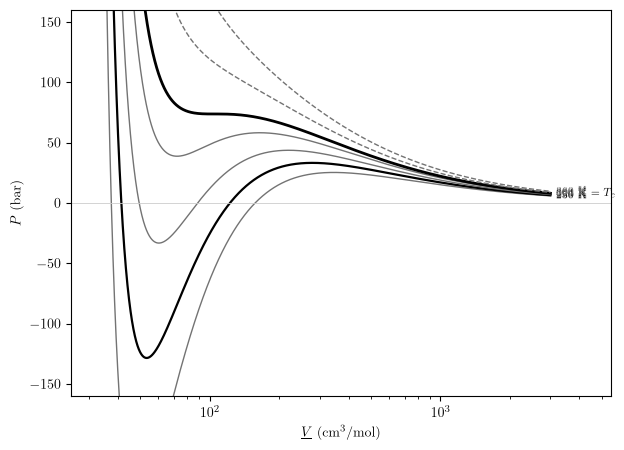

Three regimes, and the loops are the point:

  T < Tc   a maximum and a minimum. Between them dP/dV > 0.
  T = Tc   maximum and minimum have merged: (dP/dV)_T = (d2P/dV2)_T = 0 at the
           critical point, which is how Sec. 7.3 defines it.
  T > Tc   monotonic. No loop, no two-phase region, nothing to fix.

Notice how far below zero the 250 K minimum goes. Negative pressure is not a
numerical artifact — it is the equation of state describing liquid under tension —
but it is also deep inside the region Sec. 7.2 forbids.


In [3]:
fig, ax = plt.subplots(figsize=(6.4, 4.6))

V = np.logspace(np.log10(1.02*b), np.log10(3e-3), 3000)

for T, style in [(230.0, "-"), (250.0, "-"), (270.0, "-"), (290.0, "-"),
                 (Tc, "-"), (330.0, "--"), (360.0, "--")]:
    lw = 2.0 if T == Tc else (1.6 if T == T_STAR else 1.0)
    col = "black" if T in (Tc, T_STAR) else "0.45"
    ax.plot(V*CM3, pr.pressure(V, T)/BAR, style, color=col, lw=lw)
    # label at the right-hand end of each curve
    ax.annotate(rf"${T:.0f}$ K" + (r"  $=T_c$" if T == Tc else ""),
                xy=(3e-3*CM3, pr.pressure(3e-3, T)/BAR),
                xytext=(4, 0), textcoords="offset points",
                fontsize=7.5, va="center", color=col)

ax.axhline(0, color="0.8", lw=0.6)
ax.plot(np.nan, np.nan)  # keep color cycle unused

ax.set_xscale("log")
ax.set_xlabel(r"$\underline{V}$  (cm$^3$/mol)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_xlim(25, 5.5e3)
ax.set_ylim(-160, 160)
ax.set_title(None)
fig.tight_layout()
plt.show()

print(f"""Three regimes, and the loops are the point:

  T < Tc   a maximum and a minimum. Between them dP/dV > 0.
  T = Tc   maximum and minimum have merged: (dP/dV)_T = (d2P/dV2)_T = 0 at the
           critical point, which is how Sec. 7.3 defines it.
  T > Tc   monotonic. No loop, no two-phase region, nothing to fix.

Notice how far below zero the {T_STAR:.0f} K minimum goes. Negative pressure is not a
numerical artifact — it is the equation of state describing liquid under tension —
but it is also deep inside the region Sec. 7.2 forbids.""")

## Where mechanical stability fails

Rather than eyeball the turning points, compute the derivative. For the Peng&ndash;Robinson
equation

$$ P = \frac{RT}{\underline V - b}
       - \frac{a(T)}{\underline V^2 + 2b\underline V - b^2} $$

so

$$ \left(\frac{\partial P}{\partial \underline V}\right)_T
   = -\frac{RT}{(\underline V-b)^2}
     + \frac{2a(T)\,(\underline V + b)}{\left(\underline V^2 + 2b\underline V - b^2\right)^2} $$

The mechanical stability criterion (Eq. 7.2-13) is usually written in terms of the
**isothermal compressibility**, which is the physically meaningful form:

$$ \kappa_T = -\frac{1}{\underline V}
   \left(\frac{\partial \underline V}{\partial P}\right)_T
   = -\frac{1}{\underline V \left(\partial P/\partial \underline V\right)_T} > 0 $$

$\kappa_T$ is how much the fluid shrinks when you squeeze it, per unit of squeeze. A negative
$\kappa_T$ would mean a fluid that *expands* when compressed, which is why the criterion is
not a technicality: such a state would have no restoring force against a density
fluctuation, so it would separate spontaneously.

Two things to watch for in the numbers below:

- $\kappa_T$ is **positive on both branches** &mdash; and for the liquid it is two orders of
  magnitude smaller than for the vapor, which is just the statement that liquids are hard to
  compress.
- $\kappa_T$ **diverges** at the two turning points and is **negative between them**. The
  divergence is not a defect of the arithmetic; $(\partial P/\partial\underline V)_T$ passes
  through zero there, so the fluid is infinitely compressible. That is a real physical
  signature: it is why fluids scatter light strongly near the critical point, where the same
  divergence happens at a point you can actually reach.

In [4]:
def dPdV(V, T):
    """(dP/dV)_T for the Peng-Robinson equation, Pa/(m^3/mol)."""
    a = pr.a(T)
    return -R*T/(V - b)**2 + 2*a*(V + b)/(V**2 + 2*b*V - b**2)**2


def kappa_T(V, T):
    """Isothermal compressibility, 1/Pa. Positive for a mechanically stable phase."""
    return -1.0/(V*dPdV(V, T))


def spinodal_volumes(T, n=200000):
    """The molar volumes where (dP/dV)_T = 0, ascending. Empty at and above Tc."""
    grid = np.logspace(np.log10(1.0000001*b), 1.0, n)
    d = dPdV(grid, T)
    cross = np.where(np.diff(np.sign(d)) != 0)[0]
    return [optimize.brentq(lambda v: dPdV(v, T), grid[i], grid[i+1]) for i in cross]


# --- check the analytic derivative against a central difference -----------------
V_chk = np.array([45e-6, 80e-6, 200e-6, 1e-3])
h = 1e-11
cen = (pr.pressure(V_chk + h, T_STAR) - pr.pressure(V_chk - h, T_STAR))/(2*h)
print("analytic (dP/dV)_T checked against a central difference:")
print(f"  max relative difference {np.abs(cen/dPdV(V_chk, T_STAR) - 1).max():.2e}\n")

# --- the saturation state and the stability limits ------------------------------
Psat = pr.vapor_pressure(T_STAR)
vL, vV = pr.saturation_volumes(T_STAR, Psat)
vsl, vsv = spinodal_volumes(T_STAR)
print(f"at {T_STAR:.0f} K the Peng-Robinson equation gives")
print(f"  P^vap = {Psat/BAR:.2f} bar   (measured 17.9 bar — PR is 2.6% low for CO2)")
print(f"  V_L   = {vL*CM3:7.2f} cm^3/mol       V_V = {vV*CM3:.1f} cm^3/mol")
print(f"  stability limits at {vsl*CM3:.2f} and {vsv*CM3:.2f} cm^3/mol\n")

# Sample the isotherm. The two spinodal volumes are the boundary itself, where
# (dP/dV)_T is exactly zero and kappa_T is undefined: approached from one side it
# runs to +infinity, from the other to -infinity. No finite number belongs there,
# so those rows are printed as limits rather than evaluated.
samples = [(1.05*b, "compressed liquid"),
           (vL, "saturated liquid"),
           (0.5*(vL + vsl), "stretched liquid (metastable)"),
           (vsl, None),
           (100e-6, "inside the loop"),
           (200e-6, "inside the loop"),
           (vsv, None),
           (0.5*(vsv + vV), "expanded vapor (metastable)"),
           (vV, "saturated vapor"),
           (5e-3, "dilute vapor")]

print(f"{'V (cm3/mol)':>12}{'P (bar)':>11}{'(dP/dV)_T':>13}{'kappa_T (1/Pa)':>17}"
      f"{'stable?':>9}   region")
for V, where in samples:
    d = dPdV(V, T_STAR)
    if where is None:
        print(f"{V*CM3:12.2f}{pr.pressure(V, T_STAR)/BAR:11.2f}{0.0:13.3e}"
              f"{'diverges':>17}{'LIMIT':>9}   limit of stability (spinodal)")
    else:
        print(f"{V*CM3:12.2f}{pr.pressure(V, T_STAR)/BAR:11.2f}{d:13.3e}"
              f"{kappa_T(V, T_STAR):17.3e}{'yes' if d < 0 else 'NO':>9}   {where}")

print(f"""
Three things to read off.

SIGN. kappa_T > 0 on both outer branches, and < 0 strictly between the two spinodal
volumes — {vsl*CM3:.1f} to {vsv*CM3:.1f} cm^3/mol at this temperature. That negative band is what
Eq. 7.2-13 forbids, and it contains the middle root of the cubic.

MAGNITUDE. The saturated liquid has kappa_T = {kappa_T(vL, T_STAR):.2e} 1/Pa, the saturated vapor
{kappa_T(vV, T_STAR):.2e} 1/Pa — a factor of {kappa_T(vV, T_STAR)/kappa_T(vL, T_STAR):.0f}. That liquids are hard to compress and gases
are not is not assumed anywhere; it comes out of the equation of state.

DIVERGENCE. At the two boundary rows (dP/dV)_T passes through zero, so kappa_T runs
off to infinity: the fluid is infinitely compressible there. Not an artifact — the
same divergence happens at the critical point, which IS reachable, and it is why a
fluid near its critical point scatters light strongly enough to look milky.""")

analytic (dP/dV)_T checked against a central difference:
  max relative difference 1.92e-09

at 250 K the Peng-Robinson equation gives
  P^vap = 17.44 bar   (measured 17.9 bar — PR is 2.6% low for CO2)
  V_L   =   41.01 cm^3/mol       V_V = 972.6 cm^3/mol
  stability limits at 53.38 and 278.69 cm^3/mol

 V (cm3/mol)    P (bar)    (dP/dV)_T   kappa_T (1/Pa)  stable?   region
       27.99   12709.97   -1.150e+15        3.107e-11      yes   compressed liquid
       41.01      17.44   -3.956e+12        6.164e-09      yes   saturated liquid
       47.20    -108.11   -8.243e+11        2.570e-08      yes   stretched liquid (metastable)
       53.38    -128.43    0.000e+00         diverges    LIMIT   limit of stability (spinodal)
      100.00     -25.55    1.489e+11       -6.716e-08       NO   inside the loop
      200.00      29.48    1.289e+10       -3.879e-07       NO   inside the loop
      278.69      33.28    0.000e+00         diverges    LIMIT   limit of stability (spinodal)
      625.6

## The spinodal

The two turning points are the **limits of mechanical stability**. Solving
$(\partial P/\partial \underline V)_T = 0$ at each temperature and collecting the roots traces
a curve through the two-phase region: the **spinodal**. Inside it no fluid exists; outside it
a single phase is at least locally stable.

The spinodal meets the coexistence curve at exactly one place &mdash; the critical point,
where the maximum and minimum merge. That is the geometric content of the two conditions
$(\partial P/\partial\underline V)_T = 0$ and
$(\partial^2 P/\partial\underline V^2)_T = 0$ holding together.

Note where the **liquid** spinodal pressure sits: it is strongly *negative* over most of the
range. Liquid CO$_2$ at $250$ K would have to be pulled to $-128$ bar before it became
absolutely unstable. Liquids really do sustain tension &mdash; this is how water gets to the
top of a tall tree &mdash; and the spinodal is the theoretical limit of it.

In [5]:
T_line = np.linspace(220.0, Tc - 1e-6, 160)
sp = [spinodal_volumes(T) for T in T_line]
sp_liq = np.array([s[0] if len(s) == 2 else np.nan for s in sp])
sp_vap = np.array([s[1] if len(s) == 2 else np.nan for s in sp])

print(f"{'T (K)':>7}{'Tr':>7}{'V_sp,liq':>11}{'V_sp,vap':>11}"
      f"{'P_sp,liq':>11}{'P_sp,vap':>11}")
print(f"{'':7}{'':7}{'(cm3/mol)':>11}{'(cm3/mol)':>11}{'(bar)':>11}{'(bar)':>11}")
for T in [230.0, 250.0, 270.0, 290.0, 300.0, 303.5]:
    s = spinodal_volumes(T)
    print(f"{T:7.1f}{T/Tc:7.3f}{s[0]*CM3:11.2f}{s[1]*CM3:11.2f}"
          f"{pr.pressure(s[0], T)/BAR:11.2f}{pr.pressure(s[1], T)/BAR:11.2f}")

s3 = spinodal_volumes(303.5)
print(f"""
At {T_STAR:.0f} K the forbidden band runs from {vsl*CM3:.1f} to {vsv*CM3:.1f} cm^3/mol — a factor of
{vsv/vsl:.1f} in molar volume. Compare that with the coexistence band, {vL*CM3:.1f} to {vV*CM3:.0f}
cm^3/mol, a factor of {vV/vL:.0f}. The forbidden region is a small part of the two-phase
region: most of the two-phase region is not unstable at all, it is simply not a
single phase.

As T approaches Tc the two spinodal volumes close on each other and on the two
saturation volumes. At 303.5 K, 0.6 K below Tc, they differ by only a factor of
{s3[1]/s3[0]:.2f}, and both spinodal pressures are within {abs(pr.pressure(s3[1],303.5)-pr.pressure(s3[0],303.5))/BAR:.2f} bar of each other. At Tc they merge:
that is the critical point, the one place where the spinodal touches the
coexistence curve.

Note the sign of P_sp,liq. It is strongly NEGATIVE below about 285 K — the liquid
spinodal lies at negative pressure, i.e. in tension. This is why it will vanish
from the logarithmic plot at the end of the notebook, and it is the subject of the
metastability section below.""")

  T (K)     Tr   V_sp,liq   V_sp,vap   P_sp,liq   P_sp,vap
                (cm3/mol)  (cm3/mol)      (bar)      (bar)
  230.0  0.756      48.60     345.40    -247.77      25.34
  250.0  0.822      53.38     278.69    -128.43      33.28
  270.0  0.888      60.28     220.31     -33.20      43.73
  290.0  0.954      72.32     164.92      38.79      58.25
  300.0  0.987      85.31     132.75      65.39      68.36
  303.5  0.998      96.98     114.72      72.73      72.89

At 250 K the forbidden band runs from 53.4 to 278.7 cm^3/mol — a factor of
5.2 in molar volume. Compare that with the coexistence band, 41.0 to 973
cm^3/mol, a factor of 24. The forbidden region is a small part of the two-phase
region: most of the two-phase region is not unstable at all, it is simply not a
single phase.

As T approaches Tc the two spinodal volumes close on each other and on the two
saturation volumes. At 303.5 K, 0.6 K below Tc, they differ by only a factor of
1.18, and both spinodal pressures are within 

### The featured isotherm, with the forbidden band marked

This is the real-substance, real-axes version of Figure 7.3-3: one sub-critical isotherm, the
region Section 7.2 forbids shaded out, and the flat coexistence line that replaces it. The
printed figure teaches the shape; this one has numbers on both axes.

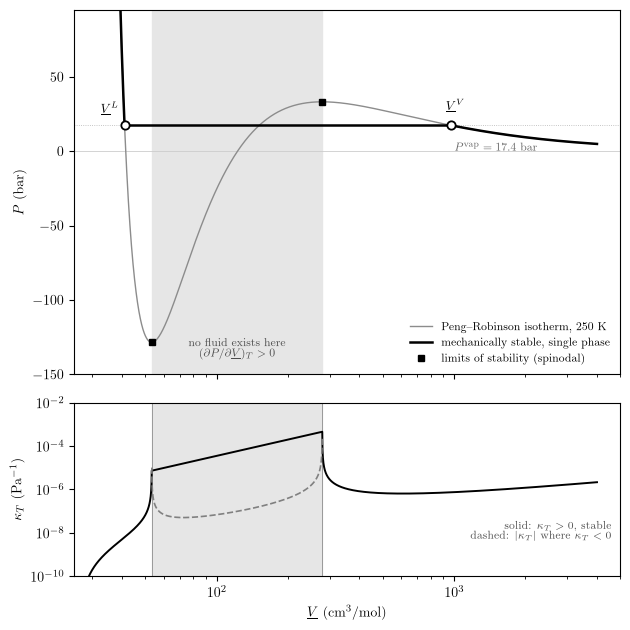

The lower panel IS the criterion. kappa_T is positive and small on the liquid
branch (6.16e-09 1/Pa), positive and large on the vapor branch (7.27e-07 1/Pa),
diverges at both edges of the shaded band, and is negative inside it — plotted
dashed as |kappa_T| so that it fits on a logarithmic axis at all.

The top panel is the same information as a shape. Note that the shaded band is
NARROWER than the coexistence line above it: the two white gaps between them, from
V_L to the left edge and from the right edge to V_V, are the metastable states.


In [6]:
fig, (ax, ax2) = plt.subplots(2, 1, figsize=(6.4, 6.4), sharex=True,
                              gridspec_kw={"height_ratios": [2.1, 1]})

V = np.logspace(np.log10(1.02*b), np.log10(4e-3), 4000)
P = pr.pressure(V, T_STAR)/BAR

# --- top panel: the isotherm ---------------------------------------------------
ax.axvspan(vsl*CM3, vsv*CM3, color="0.90", zorder=0)
ax.plot(V*CM3, P, "-", color="0.55", lw=1.0, zorder=2,
        label=rf"Peng--Robinson isotherm, ${T_STAR:.0f}$ K")

# the stable branches, heavier
ax.plot(V[V <= vL]*CM3, P[V <= vL], "-", color="black", lw=1.8, zorder=3)
ax.plot(V[V >= vV]*CM3, P[V >= vV], "-", color="black", lw=1.8, zorder=3,
        label="mechanically stable, single phase")

# the coexistence line
ax.plot([vL*CM3, vV*CM3], [Psat/BAR]*2, "-", color="black", lw=1.8, zorder=4)
ax.plot([vL*CM3, vV*CM3], [Psat/BAR]*2, "o", mfc="white", mec="black", ms=6,
        mew=1.3, zorder=5)

# the spinodal points
ax.plot([vsl*CM3, vsv*CM3],
        [pr.pressure(vsl, T_STAR)/BAR, pr.pressure(vsv, T_STAR)/BAR],
        "s", color="black", ms=5, zorder=5, label="limits of stability (spinodal)")

ax.axhline(0, color="0.8", lw=0.6, zorder=1)
ax.axhline(Psat/BAR, color="0.7", lw=0.6, ls=":", zorder=1)
ax.set_ylabel(r"$P$  (bar)")
ax.set_ylim(-150, 95)
ax.legend(frameon=False, fontsize=8, loc="lower right")

ax.annotate(r"$\underline{V}^L$", xy=(vL*CM3, Psat/BAR), xytext=(-11, 9),
            textcoords="offset points", fontsize=9, ha="center")
ax.annotate(r"$\underline{V}^V$", xy=(vV*CM3, Psat/BAR), xytext=(2, 11),
            textcoords="offset points", fontsize=9, ha="center")
ax.text(np.sqrt(vsl*vsv)*CM3, -138, "no fluid exists here\n"
        r"$(\partial P/\partial \underline{V})_T > 0$",
        fontsize=8, ha="center", color="0.3")
ax.text(1.5e3, Psat/BAR - 17, rf"$P^\mathrm{{vap}} = {Psat/BAR:.1f}$ bar",
        fontsize=8, color="0.4", ha="center")

# --- bottom panel: the compressibility ----------------------------------------
ax2.axvspan(vsl*CM3, vsv*CM3, color="0.90", zorder=0)
k = kappa_T(V, T_STAR)
pos = k > 0
ax2.plot(V[pos]*CM3, k[pos], "-", color="black", lw=1.4, zorder=3)
ax2.plot(V[~pos]*CM3, -k[~pos], "--", color="0.5", lw=1.2, zorder=3)
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_xlabel(r"$\underline{V}$  (cm$^3$/mol)")
ax2.set_ylabel(r"$\kappa_T$  (Pa$^{-1}$)")
ax2.set_xlim(25, 5e3)
ax2.set_ylim(1e-10, 1e-2)
ax2.text(4.6e3, 4e-9, "solid: " + r"$\kappa_T > 0$" + ", stable\n"
         + "dashed: " + r"$|\kappa_T|$" + " where " + r"$\kappa_T < 0$",
         fontsize=7.5, color="0.3", ha="right", va="bottom")
ax2.axvline(vsl*CM3, color="0.6", lw=0.7)
ax2.axvline(vsv*CM3, color="0.6", lw=0.7)

fig.tight_layout()
plt.show()

print(f"""The lower panel IS the criterion. kappa_T is positive and small on the liquid
branch ({kappa_T(vL, T_STAR):.2e} 1/Pa), positive and large on the vapor branch ({kappa_T(vV, T_STAR):.2e} 1/Pa),
diverges at both edges of the shaded band, and is negative inside it — plotted
dashed as |kappa_T| so that it fits on a logarithmic axis at all.

The top panel is the same information as a shape. Note that the shaded band is
NARROWER than the coexistence line above it: the two white gaps between them, from
V_L to the left edge and from the right edge to V_V, are the metastable states.""")

## What replaces the loop, and how it is found

Section 7.2 tells us the loop is not physical. It does not tell us what to draw instead. That
comes from the *chemical* condition of Eq. 7.2-15, $\underline G^L = \underline G^V$, which
Section 7.4 rewrites as equality of fugacities:

$$ f^L(T, P) = f^V(T, P) $$

At one pressure &mdash; the vapor pressure &mdash; the two outer roots of the cubic have the
same fugacity, and the horizontal line joining them replaces the loop.

**And here the spinodal does a second job.** Solving $f^L = f^V$ means
finding a root of $\ln(f^L/f^V)$, and Section 7.5 warns about the *trivial solution*: guess a
pressure outside the loop, get one root instead of three, and a solver can happily return the
guess. The cure is not a better guess &mdash; it is a **bracket**. Any pressure strictly
between the two spinodal pressures gives three distinct roots, and the residual changes sign
exactly once across that interval. So the spinodal pressures bracket the answer by
construction, and the trivial solution becomes unreachable.

That is what `thermo.CubicEOS.vapor_pressure` does, and it is the algorithm drawn in the
Figure 7.5-1 flow sheet. Below we do it by hand once, to see the bracket work.

In [7]:
P_lo, P_hi = pr.spinodal_bounds(T_STAR)
print(f"spinodal pressures at {T_STAR:.0f} K: {P_lo/BAR:.2f} to {P_hi/BAR:.2f} bar")
print(f"  the vapor pressure must lie in that interval, and does: {Psat/BAR:.2f} bar\n")

# The residual, and its sign at a few pressures inside the bracket
print(f"{'P (bar)':>10}{'ln(f_L/f_V)':>14}   what a solver sees")
for Pt in [1.0, 5.0, 10.0, Psat/BAR, 25.0, 33.0]:
    r = pr.ln_fugacity_ratio(T_STAR, Pt*BAR)
    note = ("no two-phase roots — THE TRIVIAL SOLUTION TRAP"
            if not np.isfinite(r) else
            ("zero: this is P^vap" if abs(r) < 1e-9 else
             ("f_L > f_V, P below P^vap" if r > 0 else "f_L < f_V, P above P^vap")))
    print(f"{Pt:10.2f}{r:14.6f}   {note}")

print(f"""
The first row is the failure mode Sec. 7.5 describes: at 1 bar the {T_STAR:.0f} K isotherm
has only one physical root, there is no residual to drive to zero, and a
Newton iteration started there has nothing to converge to. Bracketing between
{P_lo/BAR:.1f} and {P_hi/BAR:.1f} bar makes that state unreachable.""")

# --- the Gibbs energy test: which root is the fluid actually in? ---------------
# At fixed T and P, G_L - G_V = RT ln(f_L/f_V). Sec. 7.1: the stable phase is the
# one with the LOWER molar Gibbs energy. So the sign of the residual above is not
# just a solver diagnostic — it is the answer to "liquid or vapor?".
print(f"\n{'P (bar)':>10}{'G_L - G_V (J/mol)':>20}   stable phase")
for Pt in [8.0, 14.0, Psat/BAR, 22.0, 30.0]:
    dG = R*T_STAR*pr.ln_fugacity_ratio(T_STAR, Pt*BAR)
    which_ph = "vapor" if dG > 1e-9 else ("liquid" if dG < -1e-9 else "both — coexistence")
    print(f"{Pt:10.2f}{dG:20.1f}   {which_ph}")

print(f"""
This is the rule `properties_chart_oxygen.ipynb` applies 52 times: below P^vap the
vapor has the lower molar Gibbs energy, above it the liquid does, and the equation
of state alone cannot tell you — you need P^vap first. Sec. 7.2 rules out the middle
root; Sec. 7.1 chooses between the two that survive.""")

spinodal pressures at 250 K: -128.43 to 33.28 bar
  the vapor pressure must lie in that interval, and does: 17.44 bar

   P (bar)   ln(f_L/f_V)   what a solver sees
      1.00      2.665056   f_L > f_V, P below P^vap
      5.00      1.100978   f_L > f_V, P below P^vap
     10.00      0.465999   f_L > f_V, P below P^vap
     17.44     -0.000000   zero: this is P^vap
     25.00     -0.261571   f_L < f_V, P above P^vap
     33.00     -0.420293   f_L < f_V, P above P^vap

The first row is the failure mode Sec. 7.5 describes: at 1 bar the 250 K isotherm
has only one physical root, there is no residual to drive to zero, and a
Newton iteration started there has nothing to converge to. Bracketing between
-128.4 and 33.3 bar makes that state unreachable.

   P (bar)   G_L - G_V (J/mol)   stable phase
      8.00              1383.7   vapor
     14.00               368.9   vapor
     17.44                -0.0   both — coexistence
     22.00              -361.3   liquid
     30.00              -77

## Metastable, unstable, and why Section 7.8 exists

The shaded band and the coexistence line do not coincide, and the gap between them is not an
accident. Three distinct regions sit between $\underline V^L$ and $\underline V^V$:

| region | $\kappa_T$ | status |
|---|---|---|
| $\underline V^L$ to the liquid spinodal | $>0$ | **metastable** &mdash; a superheated (or stretched) liquid |
| between the two spinodal volumes | $<0$ | **unstable** &mdash; no fluid, ever |
| the vapor spinodal to $\underline V^V$ | $>0$ | **metastable** &mdash; a subcooled (supersaturated) vapor |

A metastable state is *locally* stable: it satisfies both criteria of Section 7.2, so small
fluctuations decay, and you can genuinely prepare one. It is only *globally* unstable, because
a two-phase mixture at the same $T$ and $P$ has a lower total Gibbs energy. What separates it
from the stable state is a **barrier** &mdash; and the barrier is exactly the surface energy
of the new phase that has to be created.

Which is where Section 7.8 comes in. A small droplet pays $2\sigma\underline V^L/r$ in molar
Gibbs energy for its curvature, so the first tiny droplet to form in a subcooled vapor is
*uphill* even though the bulk transition is downhill. Nothing in this notebook &mdash; nothing
in a bulk equation of state at all &mdash; can predict when a metastable state finally decays,
because that depends on a length scale the equation of state does not contain.
`surface_effects_droplets.ipynb` takes it from here.

Two everyday consequences: a smooth cup of water in a microwave can pass its boiling point and
then erupt when a bubble finally nucleates, and a cloud is subcooled vapor waiting for dust.

In [8]:
# How much metastable range is there? Express it as superheat at fixed pressure.
print("the metastable liquid range at each temperature, in molar volume:\n")
print(f"{'T (K)':>7}{'V_L':>10}{'V_sp,liq':>11}{'range':>9}{'P^vap':>10}{'P_sp,liq':>11}")
print(f"{'':7}{'(cm3/mol)':>10}{'(cm3/mol)':>11}{'':9}{'(bar)':>10}{'(bar)':>11}")
for T in [230.0, 250.0, 270.0, 290.0, 300.0]:
    Ps = pr.vapor_pressure(T)
    l, v = pr.saturation_volumes(T, Ps)
    s = spinodal_volumes(T)
    print(f"{T:7.1f}{l*CM3:10.2f}{s[0]*CM3:11.2f}{s[0]/l:9.2f}"
          f"{Ps/BAR:10.2f}{pr.pressure(s[0], T)/BAR:11.2f}")

print(f"""
Read the last column as a tensile strength. At 250 K, liquid CO2 in coexistence with
its vapor sits at {pr.vapor_pressure(250.)/BAR:.1f} bar; the Peng-Robinson equation says it remains
locally stable — able to resist a density fluctuation — all the way down to
{pr.pressure(spinodal_volumes(250.)[0], 250.)/BAR:.0f} bar. That is a metastable window {abs(pr.pressure(spinodal_volumes(250.)[0], 250.)/BAR - pr.vapor_pressure(250.)/BAR):.0f} bar wide.

Real liquids never reach the spinodal, because nucleation on a speck of dust or a
container wall intervenes long before. The spinodal is the limit if nothing helps
the new phase get started, and the gap between it and what you measure is the whole
subject of nucleation.""")

the metastable liquid range at each temperature, in molar volume:

  T (K)       V_L   V_sp,liq    range     P^vap   P_sp,liq
        (cm3/mol)  (cm3/mol)              (bar)      (bar)
  230.0     37.41      48.60     1.30      8.65    -247.77
  250.0     41.01      53.38     1.30     17.44    -128.43
  270.0     46.84      60.28     1.29     31.67     -33.20
  290.0     58.90      72.32     1.23     53.16      38.79
  300.0     74.73      85.31     1.14     67.27      65.39

Read the last column as a tensile strength. At 250 K, liquid CO2 in coexistence with
its vapor sits at 17.4 bar; the Peng-Robinson equation says it remains
locally stable — able to resist a density fluctuation — all the way down to
-128 bar. That is a metastable window 146 bar wide.

Real liquids never reach the spinodal, because nucleation on a speck of dust or a
container wall intervenes long before. The spinodal is the limit if nothing helps
the new phase get started, and the gap between it and what you measure

## The coexistence region

Finally, all of it at once: the coexistence envelope over the whole sub-critical range, the
spinodal inside it, tie lines at several temperatures, and the isotherms that run into the
envelope from either side. This is Figure 7.3-4's construction &mdash; *"the van der Waals
fluid with the vapor&ndash;liquid coexistence region identified"* &mdash; carried out for
carbon dioxide with the Peng&ndash;Robinson equation.

The two curves meet at the critical point and nowhere else. Everything inside the outer curve
is two phases; everything inside the inner curve is nothing at all.

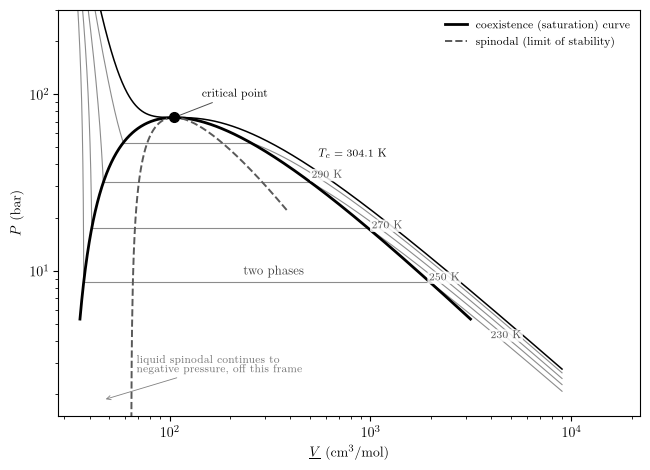

Peng-Robinson critical molar volume: 105.3 cm^3/mol, against the
measured 93.9 — +12%.

That error is structural, not a fitting problem. In a two-parameter cubic equation of
state a and b are fixed by Tc and Pc alone, which forces Zc to a single number for
every substance: 0.307 for Peng-Robinson, 0.375 for van der Waals. Carbon dioxide has
Zc = 0.274. The ratio 1.122 is exactly the +12% above, so the equation cannot
get the critical volume right for CO2 — or for anything else, since no real substance
has Zc = 0.307.

It is nonetheless good to a few percent along the saturation curve away from the
critical point, which is what makes it useful. Being wrong in a known place and by a
known amount is a usable model; the failure is worst exactly at the critical point
and improves as you move away from it.


In [9]:
# The saturation envelope. vapor_pressure() brackets between the spinodal pressures,
# so no continuation guess is needed at any temperature and there is no risk of the
# curve quietly falling onto the trivial solution partway up.
T_env = np.linspace(218.0, Tc - 0.02, 220)
env = pd.DataFrame([
    dict(zip(("T", "P", "vL", "vV"),
             (T, (Ps := pr.vapor_pressure(T)), *pr.saturation_volumes(T, Ps))))
    for T in T_env])

LABEL_BOX = dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85)

fig, ax = plt.subplots(figsize=(6.6, 4.8))

# --- isotherms, drawn only where they are stable. Each is labeled ON ITS OWN
# CURVE out in the vapor region, where the isotherms are well separated; labeling
# them all at the right-hand frame edge crowds them into an illegible stack.
for T in [230.0, 250.0, 270.0, 290.0]:
    Ps = pr.vapor_pressure(T)
    l, v = pr.saturation_volumes(T, Ps)
    Vl = np.logspace(np.log10(1.03*b), np.log10(l), 400)
    Vv = np.logspace(np.log10(v), np.log10(9e-3), 400)
    ax.plot(Vl*CM3, pr.pressure(Vl, T)/BAR, "-", color="0.55", lw=0.8)
    ax.plot(Vv*CM3, pr.pressure(Vv, T)/BAR, "-", color="0.55", lw=0.8)
    ax.plot([l*CM3, v*CM3], [Ps/BAR]*2, "-", color="0.55", lw=0.8)   # tie line
    V_lab = 2.4*v
    ax.annotate(rf"${T:.0f}$ K", xy=(V_lab*CM3, pr.pressure(V_lab, T)/BAR),
                xytext=(0, 4), textcoords="offset points", fontsize=7.5,
                ha="center", color="0.3", bbox=LABEL_BOX)

# --- the critical isotherm
Vc_line = np.logspace(np.log10(1.03*b), np.log10(9e-3), 1200)
ax.plot(Vc_line*CM3, pr.pressure(Vc_line, Tc)/BAR, "-", color="black", lw=1.1)
ax.annotate(rf"$T_c = {Tc:.1f}$ K", xy=(5e-4*CM3, pr.pressure(5e-4, Tc)/BAR),
            xytext=(6, 7), textcoords="offset points", fontsize=7.5,
            ha="left", color="black", bbox=LABEL_BOX)

# --- the coexistence envelope
ax.plot(env["vL"]*CM3, env["P"]/BAR, "-", color="black", lw=2.0,
        label="coexistence (saturation) curve")
ax.plot(env["vV"]*CM3, env["P"]/BAR, "-", color="black", lw=2.0)

# --- the spinodal. The liquid branch runs to negative pressure below ~285 K, so on
# a logarithmic ordinate it simply leaves the frame; that is physics, not a gap.
P_sp_liq = np.array([pr.pressure(v, T) for v, T in zip(sp_liq, T_line)])
P_sp_vap = np.array([pr.pressure(v, T) for v, T in zip(sp_vap, T_line)])
ax.plot(sp_liq*CM3, P_sp_liq/BAR, "--", color="0.35", lw=1.4,
        label="spinodal (limit of stability)")
ax.plot(sp_vap*CM3, P_sp_vap/BAR, "--", color="0.35", lw=1.4)

# --- the critical point. Evaluate Vc from the ANALYTIC Zc of the PR equation: at
# exactly (Tc, Pc) the cubic has a triple root, and picking the largest numerical
# root there overestimates it by a few percent.
ZC_PR = 0.307401                      # PR critical compressibility, all substances
Vc_pr = ZC_PR*R*Tc/Pc
ax.plot(Vc_pr*CM3, Pc/BAR, "o", color="black", ms=7, zorder=6)
ax.annotate("critical point", xy=(Vc_pr*CM3, Pc/BAR), xytext=(20, 15),
            textcoords="offset points", fontsize=8,
            arrowprops=dict(arrowstyle="-", lw=0.7, color="0.3"))

ax.annotate("liquid spinodal continues to\nnegative pressure, off this frame",
            xy=(sp_liq[0]*CM3, 1.85), xytext=(24, 20), textcoords="offset points",
            fontsize=7.5, color="0.45", ha="left",
            arrowprops=dict(arrowstyle="->", lw=0.6, color="0.5"))

ax.text(330, 9.5, "two phases", fontsize=9, color="0.25", ha="center")

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"$\underline{V}$  (cm$^3$/mol)")
ax.set_ylabel(r"$P$  (bar)")
ax.set_xlim(28, 2.2e4)
ax.set_ylim(1.5, 3e2)
ax.legend(frameon=False, fontsize=8, loc="upper right")
fig.tight_layout()
plt.show()

Vc_meas = 93.9   # cm^3/mol, code/data/pure_property.csv
Zc_meas = 0.274  # same row
print(f"""Peng-Robinson critical molar volume: {Vc_pr*CM3:.1f} cm^3/mol, against the
measured {Vc_meas:.1f} — {100*(Vc_pr*CM3/Vc_meas - 1):+.0f}%.

That error is structural, not a fitting problem. In a two-parameter cubic equation of
state a and b are fixed by Tc and Pc alone, which forces Zc to a single number for
every substance: {ZC_PR:.3f} for Peng-Robinson, 0.375 for van der Waals. Carbon dioxide has
Zc = {Zc_meas}. The ratio {ZC_PR/Zc_meas:.3f} is exactly the {100*(ZC_PR/Zc_meas - 1):+.0f}% above, so the equation cannot
get the critical volume right for CO2 — or for anything else, since no real substance
has Zc = {ZC_PR:.3f}.

It is nonetheless good to a few percent along the saturation curve away from the
critical point, which is what makes it useful. Being wrong in a known place and by a
known amount is a usable model; the failure is worst exactly at the critical point
and improves as you move away from it.""")

## What this notebook shows

**Section 7.2 is doing real work.** It is easy to read $C_V > 0$ and
$(\partial P/\partial\underline V)_T < 0$ as bookkeeping. They are not: the second one deletes
a stretch of every sub-critical isotherm a cubic equation of state produces. Without it the
Peng&ndash;Robinson equation would predict, at $250$ K and $10$ bar, three different molar
volumes for carbon dioxide with no basis for choosing among them.

**The criteria and the choice are two different steps.** Mechanical stability rules out the
*middle* root &mdash; permanently, on the grounds that it has $\kappa_T < 0$. It says nothing
about which of the two survivors the fluid is in. That takes the chemical condition
$\underline G^L = \underline G^V$, equivalently $f^L = f^V$, and the answer depends on whether
you are above or below $P^\mathrm{vap}$. Two criteria, two jobs, in that order.

**$\kappa_T$ is the physical form of the criterion, and its divergence is real.** Compressibility
going to infinity at the spinodal is the same divergence that makes fluids near their critical
point scatter light so strongly that they turn milky. The criterion is not an inequality
invented to tidy up an equation of state; it is a statement about whether a density
fluctuation grows or decays.

**The spinodal is both a boundary and a tool.** As a boundary it separates metastable from
unstable, which is what makes superheating, subcooling, and the tensile strength of liquids
possible to discuss at all. As a tool it is the bracket that makes the Section 7.4
equal-fugacity calculation reliable: between the two spinodal pressures the residual has
exactly one sign change, so the trivial solution the text warns about cannot be reached. The
Figure 7.5-1 flow sheet is drawn around that fact.

**A two-parameter cubic cannot get the critical point right.** $Z_c$ is fixed at 0.307 by the
form of the Peng&ndash;Robinson equation, and CO$_2$ has 0.274, so the predicted critical
molar volume is 12% high. Knowing where a model must fail is part of using it.

**And where this leaves the printed figures.** Figure 7.3-3 shows this isotherm on unlabeled
axes, drawn from the *reduced* van der Waals equation &mdash; a shape, deliberately without a
substance. Everything above is the same shape with a substance, an equation of state fitted to
that substance, and numbers on both axes. The comparison is worth making in both directions:
the shape is right, and the numbers are what you would have had to compute anyway.

### Things to try

1. **Find the tensile strength of water.** Repeat the spinodal calculation for water at
   $20\,^\circ$C using `PengRobinson.from_database("water")`, and compare the liquid spinodal
   pressure with the roughly $-1000$ bar that experiments on water inclusions in quartz
   reach. Peng&ndash;Robinson is poor for water (see `vapor_pressure_water.ipynb`) &mdash; does
   PRSV with $\kappa_1$ help here, or is the discrepancy about something else?

2. **Verify the critical point conditions directly.** Compute
   $(\partial P/\partial \underline V)_T$ and
   $(\partial^2 P/\partial \underline V^2)_T$ at $(T_c, \underline V_c^{\mathrm{PR}})$ and check
   that both vanish. Then show analytically that this forces $Z_c = 0.307$ for the
   Peng&ndash;Robinson equation, independent of the substance.

3. **Compare the spinodal with the Maxwell equal-area construction.** The coexistence line was
   located here by equal fugacity. The classical alternative is to place it so that the two
   areas between the line and the loop are equal. Show numerically that they give the same
   pressure, then explain why &mdash; what integral is $\int \underline V \, dP$ along the
   isotherm, and what does the equal-area condition say about
   $\underline G^V - \underline G^L$?

4. **Do the van der Waals equation alongside.** `thermo.VanDerWaals` has the same interface.
   How much wider is the vdW loop at $T_r = 0.82$, how far off is its vapor pressure, and how
   does its fixed $Z_c = 0.375$ compare with Peng&ndash;Robinson's 0.307?

5. **How much does the rejected root cost?** At $250$ K and $10$ bar, compute
   $\underline H$ and $\underline S$ for *both* stable roots using
   `pr.departure_H` and `pr.departure_S`. `properties_chart_oxygen.ipynb` finds differences up
   to $7100$ J/mol in $\underline H$ for oxygen. What is it here, and what would happen to a
   heat-duty calculation that picked the wrong one?

6. **Reproduce the old version of this plot.** Set the ordinate to a linear axis with
   `ylim([0, 10])` and observe that the loops vanish from the frame entirely. Then decide what
   the earlier notebook was actually showing when it drew CO$_2$ isotherms that way.